<a href="https://colab.research.google.com/github/badaraaliouguindo/sentiment-analysis-multilingual/blob/main/notebooks/02_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chargement des données

In [1]:
!pip install datasets transformers torch scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Rechargement
dataset_en = load_dataset("stanfordnlp/sst2", split="train[:5000]")
df_en = dataset_en.to_pandas()[['sentence', 'label']].rename(columns={'sentence': 'text'})
df_en['language'] = 'english'

dataset_fr = load_dataset("allocine", split="train[:5000]")
df_fr = dataset_fr.to_pandas()[['review', 'label']].rename(columns={'review': 'text'})
df_fr['language'] = 'french'

df = pd.concat([df_en, df_fr], ignore_index=True)
df['text'] = df['text'].astype(str)

print("Dataset prêt :", df.shape)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

allocine/test-00000-of-00001.parquet:   0%|          | 0.00/7.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Dataset prêt : (10000, 3)


# Split train/test

In [2]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train)} | Test : {len(X_test)}")
print(f"Proportion cible train : {y_train.mean():.2f}")
print(f"Proportion cible test  : {y_test.mean():.2f}")

Train : 8000 | Test : 2000
Proportion cible train : 0.52
Proportion cible test  : 0.52


# Baseline TF-IDF + Logistic Regression

In [3]:
# TF-IDF : transforme chaque texte en vecteur de fréquences de mots
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Logistic Regression : classifieur simple et rapide
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
y_proba_lr = lr.predict_proba(X_test_tfidf)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=== BASELINE : TF-IDF + Logistic Regression ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['Négatif', 'Positif']))
print(f"AUC-ROC : {auc_lr:.4f}")

=== BASELINE : TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

     Négatif       0.83      0.75      0.79       952
     Positif       0.79      0.86      0.82      1048

    accuracy                           0.81      2000
   macro avg       0.81      0.80      0.80      2000
weighted avg       0.81      0.81      0.80      2000

AUC-ROC : 0.8968


# Visualisation de la matrice de confusion TF-IDF

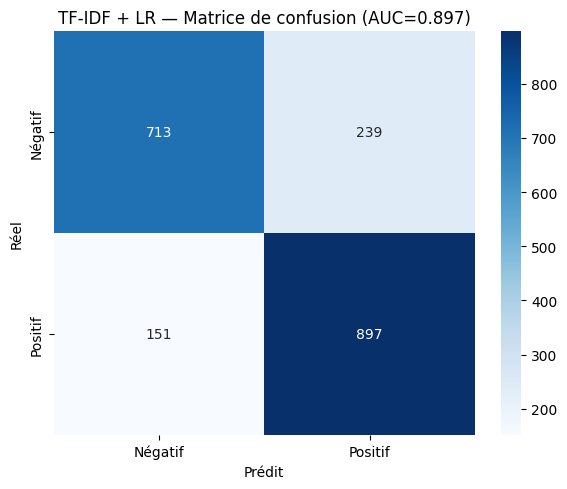

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'])
ax.set_title(f"TF-IDF + LR — Matrice de confusion (AUC={auc_lr:.3f})")
ax.set_ylabel("Réel")
ax.set_xlabel("Prédit")
plt.tight_layout()
plt.show()

# Les mots les plus importants selon TF-IDF

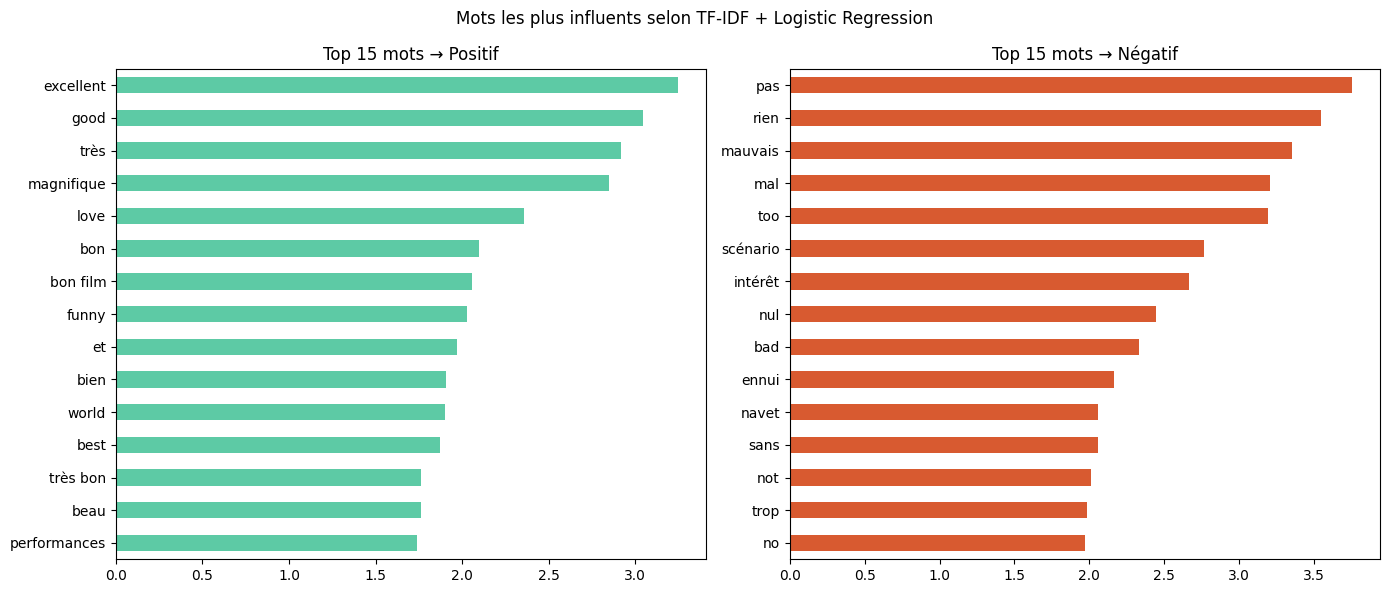

In [5]:
# On regarde quels mots TF-IDF associe au positif et au négatif
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_positifs = pd.Series(coefs, index=feature_names).nlargest(15)
top_negatifs = pd.Series(coefs, index=feature_names).nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_positifs.plot(kind='barh', ax=axes[0], color='#5DCAA5')
axes[0].set_title("Top 15 mots → Positif")
axes[0].invert_yaxis()

top_negatifs.abs().plot(kind='barh', ax=axes[1], color='#D85A30')
axes[1].set_title("Top 15 mots → Négatif")
axes[1].invert_yaxis()

plt.suptitle("Mots les plus influents selon TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

# Préparation pour BERT

In [6]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from torch.utils.data import Dataset
import torch

# Modèle multilingue léger — comprend français ET anglais
MODEL_NAME = "distilbert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

# On prend un sous-ensemble pour que ça tourne vite sur Colab
# 2000 train, 500 test — suffisant pour démontrer la puissance de BERT
X_train_bert = X_train.reset_index(drop=True)[:2000]
y_train_bert = y_train.reset_index(drop=True)[:2000]
X_test_bert  = X_test.reset_index(drop=True)[:500]
y_test_bert  = y_test.reset_index(drop=True)[:500]

print(f"Train BERT : {len(X_train_bert)} | Test BERT : {len(X_test_bert)}")
print("Tokenizer chargé !")

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train BERT : 2000 | Test BERT : 500
Tokenizer chargé !


# Dataset pytorch

In [7]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = SentimentDataset(X_train_bert, y_train_bert, tokenizer)
test_dataset  = SentimentDataset(X_test_bert,  y_test_bert,  tokenizer)

print("Datasets PyTorch créés !")
print(f"Exemple — input_ids shape : {train_dataset[0]['input_ids'].shape}")

Datasets PyTorch créés !
Exemple — input_ids shape : torch.Size([128])


# Fine-Tuning Bert

In [8]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

# Chargement du modèle
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# Fonction d'évaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probas = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        'accuracy': accuracy_score(labels, predictions),
        'auc_roc':  roc_auc_score(labels, probas)
    }

# Configuration de l'entraînement
training_args = TrainingArguments(
    output_dir         = './bert_results',
    num_train_epochs   = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps       = 100,
    weight_decay       = 0.01,
    eval_strategy      = "epoch",
    save_strategy      = "epoch",
    load_best_model_at_end = True,
    logging_steps      = 50,
    report_to          = "none"
)

trainer = Trainer(
    model           = model_bert,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)

print("Lancement du fine-tuning...")
trainer.train()

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Lancement du fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Auc Roc
1,0.657080,0.492176,0.774000,0.838748
2,0.472421,0.453680,0.804000,0.882913
3,0.185152,0.568729,0.808000,0.892611


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=375, training_loss=0.43578300603230796, metrics={'train_runtime': 188.7346, 'train_samples_per_second': 31.791, 'train_steps_per_second': 1.987, 'total_flos': 198701097984000.0, 'train_loss': 0.43578300603230796, 'epoch': 3.0})

# Évaluation et comparaison finale

In [9]:
# Évaluation BERT
results_bert = trainer.evaluate()
auc_bert     = results_bert['eval_auc_roc']
acc_bert     = results_bert['eval_accuracy']

# Comparaison
print("=" * 50)
print("       COMPARAISON TF-IDF vs BERT")
print("=" * 50)
print(f"{'Modèle':<30} {'AUC-ROC':<12} {'Accuracy'}")
print("-" * 50)

from sklearn.metrics import accuracy_score as acc
acc_lr = acc(y_test, y_pred_lr)
print(f"{'TF-IDF + Logistic Regression':<30} {auc_lr:<12.4f} {acc_lr:.4f}")
print(f"{'DistilBERT multilingue':<30} {auc_bert:<12.4f} {acc_bert:.4f}")
print("=" * 50)

gain = (auc_bert - auc_lr) * 100
print(f"\nGain BERT vs TF-IDF : +{gain:.2f} points d'AUC")

       COMPARAISON TF-IDF vs BERT
Modèle                         AUC-ROC      Accuracy
--------------------------------------------------
TF-IDF + Logistic Regression   0.8968       0.8050
DistilBERT multilingue         0.8829       0.8040

Gain BERT vs TF-IDF : +-1.39 points d'AUC


# Sauvegarde du modèle BERT

In [10]:
# Sauvegarde du modèle fine-tuné
model_bert.save_pretrained("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

print("Modèle sauvegardé dans ./sentiment_model/")
print("\nFichiers créés :")
import os
for f in os.listdir("./sentiment_model"):
    print(f"  - {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé dans ./sentiment_model/

Fichiers créés :
  - model.safetensors
  - tokenizer.json
  - config.json
  - tokenizer_config.json
